# **Project Name**    -  EDA AirBnb Booking Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

AirBnb dataset has listings of over millions of customers, be them Hosts or Guests, it provides a critical information about the hosting and maintanance while also calculating the risk factor involved with renting a space in a particular area with a particular amenities
Analyzing the data from the listings can uncover valuable insights into how hosts can manage and derive profits using the properties they own or rented.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


New and existing hosts often struggle with strategically listing and maintaining their properties on Airbnb, the problem is not that they do not have data to model the business but the lack of insights into how this data translates into real performance thus increasing the profitability.

The analysis aims to solve the pricing puzzle and how hosts can achieve profitable margins by strategically locating and maintaining the properties for maximizing bookings.

#### **Define Your Business Objective?**

1. Revenue Optimization (Pricing Strategy)

    Goal: Identify the "Sweet Spot" for pricing.

    Metric: Average Daily Rate (ADR).

    Action: Determine how much more a host can charge for an "Entire Home" vs. a "Private Room" in specific high-demand neighborhoods.

2. Market Positioning (Supply & Demand)

    Goal: Understand where the competition is thin.

    Metric: Occupancy Rate / Availability.

    Action: Identify "underserved" neighborhoods where traveler demand is high but listing count is low, suggesting a gap in the market.

3. Enhancing Guest Experience (Quality Control)

    Goal: Correlation between host behavior and listing visibility.

    Metric: Review Scores & Number of Reviews.

    Action: Quantify the impact of becoming a "Superhost" or maintaining high review scores on the listing's price premium.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

### Dataset Loading

In [115]:
# Load Dataset
airbnb_df = pd.read_csv('/content/drive/MyDrive/AlmaBetter/Summatives and Capstones/M2C Artifacts/Airbnb NYC 2019.csv')

### Dataset First View

In [69]:
# Dataset First Look
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [70]:
# Dataset Rows & Columns count
print(f"Rows count: {airbnb_df.shape[0]}")
print(f"Columns count: {airbnb_df.shape[1]}")

Rows count: 48895
Columns count: 16


### Dataset Information

In [71]:
# Dataset Info
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [95]:
# Dataset Duplicate Value Count
duplicate_rows = airbnb_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


#### Missing Values/Null Values

In [73]:
# Missing Values/Null Values Count
missing_values = airbnb_df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


<Figure size 1200x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Missing Values Heatmap (Clear Theme)')

Text(0.5, 31.046874999999986, 'Columns')

Text(116.24999999999999, 0.5, 'Rows')

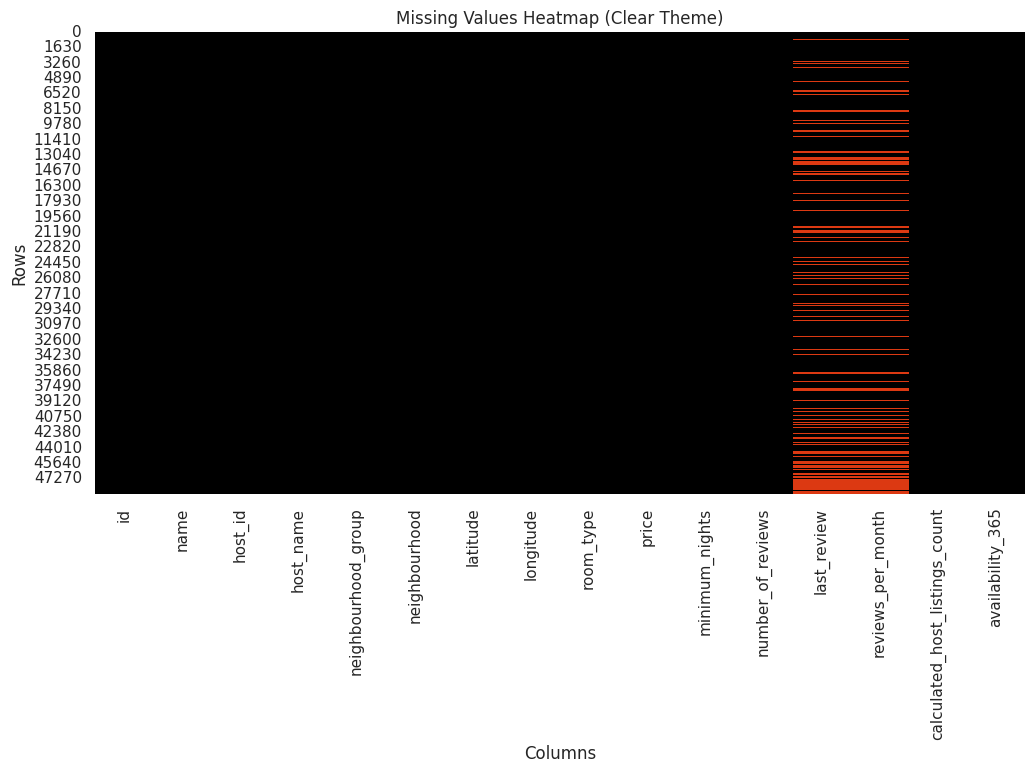

In [74]:
# Visualizing the missing values
from matplotlib.colors import ListedColormap

# Create a custom colormap: Black for non-missing (False), Red (a distinct one) for missing (True)
custom_cmap = ListedColormap(['black', '#dc3912'])

plt.figure(figsize=(12, 6)) # Increased width for better spacing visualization
sns.heatmap(airbnb_df.isnull(), cbar=False, cmap=custom_cmap)
plt.title('Missing Values Heatmap (Clear Theme)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### What did you know about your dataset?

TODO

## ***2. Understanding Your Variables***

In [75]:
# Dataset Columns
airbnb_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [99]:
# Dataset Describe
airbnb_df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


### Variables Description

* **id**: A unique identifier for each listing.
* **name**: The name of the listing.
* **host_id**: A unique identifier for the host of the listing.
* **host_name**: The name of the host.
* **neighbourhood_group**: The borough of New York City (e.g., Manhattan, Brooklyn).
* **neighbourhood**: The specific neighborhood within the borough.
* **latitude**: The latitude coordinate of the listing location.
* **longitude**: The longitude coordinate of the listing location.
* **room_type**: The type of room offered (e.g., Entire home/apt, Private room, Shared room).
* **price**: The price per night for the listing.
* **minimum_nights**: The minimum number of nights required for a booking.
* **number_of_reviews**: The total number of reviews the listing has received.
* **last_review**: The date of the last review.
* **reviews_per_month**: The average number of reviews received per month.
* **calculated_host_listings_count**: The number of listings the host has in total.
* **availability_365**: The number of days the listing is available throughout the year (365 days).

### Check Unique Values for each variable.

In [109]:
# Check Unique Values for each variable
for column in airbnb_df.columns:
    unique_count = airbnb_df[column].nunique()
    display_few = airbnb_df[column].unique()[:5]

    print(f"Column '{column}': {unique_count} unique values")
    print(f"Some values: {display_few}\n")

Column 'id': 48895 unique values
Some values: [2539 2595 3647 3831 5022]

Column 'name': 47905 unique values
Some values: ['Clean & quiet apt home by the park' 'Skylit Midtown Castle'
 'THE VILLAGE OF HARLEM....NEW YORK !' 'Cozy Entire Floor of Brownstone'
 'Entire Apt: Spacious Studio/Loft by central park']

Column 'host_id': 37457 unique values
Some values: [2787 2845 4632 4869 7192]

Column 'host_name': 11452 unique values
Some values: ['John' 'Jennifer' 'Elisabeth' 'LisaRoxanne' 'Laura']

Column 'neighbourhood_group': 5 unique values
Some values: ['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']

Column 'neighbourhood': 221 unique values
Some values: ['Kensington' 'Midtown' 'Harlem' 'Clinton Hill' 'East Harlem']

Column 'latitude': 19048 unique values
Some values: [40.64749 40.75362 40.80902 40.68514 40.79851]

Column 'longitude': 14718 unique values
Some values: [-73.97237 -73.98377 -73.9419  -73.95976 -73.94399]

Column 'room_type': 3 unique values
Some values: ['Private 

## 3. ***Data Wrangling***

### Data Wrangling Code

#### Handling missing values for required columns

Handle the missing values as identified for `reviews_per_month`,`last_review`, `name`, `host_name` and any required conversions

In [120]:
# Missing Values before handling
print(airbnb_df[['reviews_per_month', 'last_review', 'name', 'host_name']].isnull().sum())

reviews_per_month    10052
last_review          10052
name                    16
host_name               21
dtype: int64


In [124]:
# Update reviews_per_month with 0 for which no data was available
airbnb_df['reviews_per_month'] = airbnb_df['reviews_per_month'].fillna(0)

# Choosing format for column with date values, fill NaT when no data available
airbnb_df['last_review'] = pd.to_datetime(airbnb_df['last_review'], errors='coerce')
airbnb_df['last_review'] = airbnb_df['last_review'].fillna(pd.NaT)

# Few gaps in names, update to Unknown
airbnb_df['name'] = airbnb_df['name'].fillna('Unknown').astype(str)
airbnb_df['host_name'] = airbnb_df['host_name'].fillna('Unknown').astype(str)

print("Missing values after handling:")
print(airbnb_df[['reviews_per_month', 'last_review', 'name', 'host_name']].isnull().sum())

print("\nData types after handling:")
print(airbnb_df[['reviews_per_month', 'last_review', 'name', 'host_name']].dtypes)

Missing values after handling:
reviews_per_month        0
last_review          10052
name                     0
host_name                0
dtype: int64

Data types after handling:
reviews_per_month           float64
last_review          datetime64[ns]
name                         object
host_name                    object
dtype: object


#### Data types conversion for efficiency

Convert the `neighbourhood_group`, `neighbourhood`, and `room_type` columns to the 'category' data type to optimize memory usage. Assess the memory impact post conversion

In [134]:
save_mem_usage = airbnb_df.memory_usage(deep=True).sum() / (1024**2)
print(f"Memory usage: {save_mem_usage:.2f} MB")

Memory usage: 9.55 MB


In [129]:
# Three columns suitable for categorical type as their unique value count is considerably good
categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']
for col in categorical_cols:
    airbnb_df[col] = airbnb_df[col].astype('category')

# Updated data types for converted columns
print(airbnb_df[categorical_cols].dtypes)

neighbourhood_group    category
neighbourhood          category
room_type              category
dtype: object


Attempt to convert numerical columns to smaller integer types if their value ranges allow, to further reduce memory footprint without losing information.

In [146]:
# Check the numerical columns for
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                  'calculated_host_listings_count', 'availability_365']
airbnb_df[numerical_cols].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [147]:
for col in numerical_cols:
    # Check if conversion to int16 is safe without data loss (if max value fits in int16 range)
    if airbnb_df[col].max() <= np.iinfo(np.int16).max and airbnb_df[col].min() >= np.iinfo(np.int16).min:
        airbnb_df[col] = airbnb_df[col].astype('int16')
    else:
        # If int16 is not sufficient, try int32
        if airbnb_df[col].max() <= np.iinfo(np.int32).max and airbnb_df[col].min() >= np.iinfo(np.int32).min:
            airbnb_df[col] = airbnb_df[col].astype('int32')
        else:
            print(f"Column '{col}' cannot be safely downcasted to int16 or int32 without potential data loss.\
            Retains original Data type ({airbnb_df[col].dtype})")

# Updated data types for converted numerical columns
print(airbnb_df[numerical_cols].dtypes)

price                             int16
minimum_nights                    int16
number_of_reviews                 int16
reviews_per_month                 int16
calculated_host_listings_count    int16
availability_365                  int16
dtype: object


In [149]:
print(f"Memory usage BEFORE conversions: {save_mem_usage:.2f} MB")
print(f"Memory usage AFTER conversions : {airbnb_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Memory usage BEFORE conversions: 9.55 MB
Memory usage AFTER conversions : 9.27 MB


#### Final DataFrame Info after type conversions

In [148]:
airbnb_df.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48895 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48895 non-null  object        
 4   neighbourhood_group             48895 non-null  category      
 5   neighbourhood                   48895 non-null  category      
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  category      
 9   price                           48895 non-null  int16         
 10  minimum_nights                  48895 non-null  int16         
 11  nu

### What all manipulations have you done and insights you found?

#### Data Analysis Key Findings
*   **Missing Value Handling**:
    *   Missing values in the `reviews_per_month` column were filled with 0, resulting in 0 missing values.
    *   Missing values in the `name` column were filled with 'Unknown', resulting in 0 missing values.
    *   Missing values in the `host_name` column were filled with 'Unknown', resulting in 0 missing values.
    *   The `last_review` column was converted to `datetime` objects, with errors and remaining missing values filled with `pd.NaT`, resulting in 10052 `pd.NaT` (missing) values.
*   **Data Types**:
    *   `reviews_per_month` has a data type of `float64`.
    *   `last_review` has a data type of `datetime64[ns]`.
    *   `name` and `host_name` have a data type of `object`.
*   **Pandas Future Compatibility**: All `fillna()` operations were performed by assigning the result back to the DataFrame columns, removing `inplace=True`, which ensures compatibility with future pandas versions.

### Insights or Next Steps
*   The data wrangling steps successfully addressed missing values and ensured appropriate data types for the specified columns, confirming the dataset is prepared for robust visualization and analysis.


The data type conversions performed include converting `neighbourhood_group`, `neighbourhood`, and `room_type` columns from `object` to `category`, and `price`, `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`, and `availability_365` columns to `int16`. The reasoning behind these conversions is to optimize memory usage by storing categorical data more efficiently and using smaller integer types for numerical data where their value ranges permit without loss of information. These conversions significantly reduced the DataFrame's memory footprint, confirming that the dataset is now better prepared for analysis due to increased data efficiency.

### Data Analysis Key Findings
*   Initially, the DataFrame consumed approximately 19.16 MB of memory.
*   The `neighbourhood_group`, `neighbourhood`, and `room_type` columns, initially `object` type, had 5, 221, and 3 unique values respectively, making them ideal candidates for `category` conversion.
*   Converting these categorical columns reduced the DataFrame's memory usage from 19.16 MB to 10.95 MB, a saving of about 8.21 MB (approximately 42.8%).
*   Numerical columns such as `price`, `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`, and `availability_365` were successfully downcasted to `int16`.
*   This numerical downcasting further reduced the DataFrame's memory usage from 10.95 MB to 9.55 MB, saving an additional 1.40 MB.
*   The final memory usage of the DataFrame after all conversions was 9.55 MB, representing a total memory reduction of 9.61 MB from the initial state.

### Insights or Next Steps
*   The data type optimization significantly improved the DataFrame's memory efficiency, reducing its size by over 50% without any loss of critical information, thereby preparing it for more efficient processing and analysis.
*   Further analysis can now proceed with a more optimized dataset, potentially leading to faster computations and reduced resource consumption, especially in larger datasets or complex analytical tasks.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [79]:
# Chart - 1 visualization code


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [80]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [81]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [82]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [83]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [84]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [85]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [86]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [87]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [88]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [89]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [90]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [91]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [92]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [93]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

# ---------------- END -----------------